# Test Landmarks

In [1]:
import tensorflow as tf
import tensorflow_io as tfio
import tensorflow_addons as tfa
from tensorflow.keras.models import load_model

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2
from itertools import combinations

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed
import face_recognition
import random
from scipy.interpolate import LinearNDInterpolator
from scipy import stats

import mediapipe as mp

2023-05-17 12:40:40.911657: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-17 12:40:41.118265: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-17 12:40:42.148782: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/rafael/miniconda3/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode unti

In [2]:
TESTING_COHERENCE_LOSS = "l1"
TESTING_MAIN_LOSS = "l1"

# Dimensions
BATCH_SIZE = 20
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3


STEPS = 100000

LAMBDA1 = 1000
LAMBDA2 = 200

VIDEOS_FOLDER = 'mug64'

N_LANDMARKS = 68

In [3]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [4]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [5]:
def default_landmarks(): # TODO: change to worst case landmarks
    landmars = np.array([
        [0.29012445, 0.46152872],
        [0.2892933 , 0.5601992 ],
        [0.2931674 , 0.60794365],
        [0.3160373 , 0.7112384 ],
        [0.33694965, 0.75203294],
        [0.3611762 , 0.7809247 ],
        [0.41771138, 0.82153064],
        [0.47449082, 0.84470284],
        [0.5121861 , 0.84691584],
        [0.54917306, 0.8418585 ],
        [0.600678  , 0.81461644],
        [0.64821094, 0.77014446],
        [0.6676827 , 0.74018675],
        [0.6844234 , 0.69848907],
        [0.7026569 , 0.5953291 ],
        [0.70517784, 0.54816395],
        [0.7053476 , 0.4507432 ],
        [0.31499407, 0.4301809 ],
        [0.3496217 , 0.41683587],
        [0.3800801 , 0.4043182 ],
        [0.41894913, 0.40356678],
        [0.46308845, 0.4068857 ],
        [0.55364776, 0.40440607],
        [0.59623   , 0.39843333],
        [0.63251084, 0.39682683],
        [0.6602349 , 0.40741068],
        [0.6877083 , 0.419833  ],
        [0.5091903 , 0.4663502 ],
        [0.51167095, 0.5154015 ],
        [0.5140266 , 0.55779254],
        [0.51499516, 0.5852076 ],
        [0.47420424, 0.62131006],
        [0.49072832, 0.6327596 ],
        [0.51303864, 0.63169634],
        [0.53469867, 0.6317114 ],
        [0.55023676, 0.61953837],
        [0.36748627, 0.49156916],
        [0.389509  , 0.47794613],
        [0.42158607, 0.47474214],
        [0.45398962, 0.49241695],
        [0.4244432 , 0.50182253],
        [0.3926721 , 0.5021153 ],
        [0.56044996, 0.48936403],
        [0.5910041 , 0.46954608],
        [0.6231319 , 0.47053385],
        [0.6443183 , 0.48294783],
        [0.62151766, 0.49532306],
        [0.58998615, 0.49713737],
        [0.43043962, 0.7109368 ],
        [0.46534333, 0.6881037 ],
        [0.48942912, 0.6805593 ],
        [0.51225406, 0.6830868 ],
        [0.5341855 , 0.6793185 ],
        [0.55653214, 0.6858657 ],
        [0.5862155 , 0.7075139 ],
        [0.5538744 , 0.7318629 ],
        [0.5344313 , 0.73881537],
        [0.5121652 , 0.74083835],
        [0.48921126, 0.7400408 ],
        [0.46820667, 0.734128  ],
        [0.44096255, 0.7079656 ],
        [0.4936156 , 0.7052665 ],
        [0.5114745 , 0.70541674],
        [0.52808297, 0.70446116],
        [0.5756917 , 0.7052983 ],
        [0.52984923, 0.708476  ],
        [0.51168627, 0.7092654 ],
        [0.49262676, 0.7093172 ]], dtype=np.float32)
    return landmars + tf.random.uniform(landmars.shape, -0.1, 0.1)

In [6]:
def landmarks_to_array_dlib(landmarks):
    x = []
    y = []
    for current_landmarks in landmarks:
        x.append(current_landmarks.x)
        y.append(current_landmarks.y)
    return np.array([x, y])

def preprocess_and_detect_landmarks_dlib_numpy(clip): # TODO: normalize landmarks by the distance between the eyes
    clip_landmarks = []
    for frame in clip:
        frame =  normalized_sequence_to_images(frame)
        frame = np.array(frame, dtype=np.uint8)
        # Only considering the first face
        faces = face_recognition.api._raw_face_landmarks(face_image=frame)
        if len(faces) > 0:
            landmarks_array = landmarks_to_array_dlib(faces[0].parts())
            clip_landmarks.append(landmarks_array) # TODO: fix to work with batch size > 1
    if len(clip_landmarks) > 0:
        clip_landmarks = np.array(clip_landmarks)
        clip_landmarks = np.moveaxis(clip_landmarks, 1, 2)
    else:
        clip_landmarks = default_landmarks()
        clip_landmarks = np.expand_dims(clip_landmarks, axis=0)
    return np.ndarray.astype(clip_landmarks, dtype=np.float32)

def preprocess_and_detect_landmarks_dlib(images):
    num_frames = images.shape[0]
    [results,] = tf.numpy_function(preprocess_and_detect_landmarks_dlib_numpy, [images], Tout=[tf.float32])
    results = tf.convert_to_tensor(results, dtype=tf.float32)
    results.set_shape((num_frames, N_LANDMARKS, 2)) # TODO: fix to consider batch size
    results = tf.expand_dims(results, axis=0)
    return results    

In [7]:
current_video = np.load("../data/mug64/001/happiness/take001/video.npy")
current_landmarks = preprocess_and_detect_landmarks_dlib_numpy(current_video)
print(current_landmarks.shape)

2023-05-17 12:40:48.317791: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14121 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


(96, 68, 2)


In [8]:
DEFAULT_TRIANGULATION = [
    [78, 14, 77],
    [2, 90, 89],
    [85, 79, 80],
    [79, 12, 78],
    [12, 79, 85],
    [13, 93, 14],
    [78, 13, 14],
    [12, 13, 78],
    [12, 11, 104],
    [84, 11, 85],
    [11, 12, 85],
    [91, 81, 86],
    [4, 91, 90],
    [91, 4, 81],
    [82, 7, 83],
    [6, 7, 82],
    [107, 106, 71],
    [106, 70, 71],
    [72, 107, 71],
    [1, 2, 89],
    [13, 92, 93],
    [92, 13, 12],
    [75, 73, 74],
    [16, 76, 77],
    [25, 44, 24],
    [45, 44, 25],
    [3, 90, 2],
    [3, 4, 90],
    [9, 84, 83],
    [22, 21, 107],
    [21, 106, 107],
    [108, 72, 73],
    [72, 108, 107],
    [108, 25, 24],
    [107, 108, 24],
    [69, 87, 68],
    [105, 69, 70],
    [105, 106, 19],
    [106, 105, 70],
    [88, 0, 89],
    [0, 1, 89],
    [87, 0, 88],
    [5, 6, 82],
    [81, 5, 82],
    [4, 5, 81],
    [92, 54, 93],
    [54, 35, 93],
    [35, 54, 53],
    [54, 12, 104],
    [54, 92, 12],
    [93, 15, 14],
    [14, 15, 77],
    [15, 16, 77],
    [95, 45, 25],
    [95, 15, 45],
    [15, 95, 16],
    [44, 23, 24],
    [23, 107, 24],
    [23, 22, 107],
    [3, 96, 4],
    [96, 5, 4],
    [7, 8, 83],
    [8, 9, 83],
    [10, 11, 84],
    [9, 10, 84],
    [11, 10, 104],
    [18, 105, 19],
    [17, 87, 69],
    [17, 0, 87],
    [105, 17, 69],
    [18, 17, 105],
    [0, 99, 1],
    [17, 99, 0],
    [99, 17, 18],
    [35, 34, 30],
    [32, 31, 30],
    [31, 49, 48],
    [33, 32, 30],
    [34, 33, 30],
    [5, 100, 6],
    [100, 96, 48],
    [96, 100, 5],
    [64, 54, 104],
    [26, 95, 25],
    [95, 26, 16],
    [75, 26, 73],
    [26, 75, 76],
    [16, 26, 76],
    [26, 108, 73],
    [108, 26, 25],
    [23, 43, 22],
    [43, 23, 44],
    [43, 42, 22],
    [94, 15, 93],
    [15, 94, 45],
    [35, 94, 93],
    [94, 35, 30],
    [38, 20, 21],
    [106, 20, 19],
    [21, 20, 106],
    [41, 40, 98],
    [99, 36, 1],
    [36, 41, 98],
    [1, 36, 98],
    [36, 99, 18],
    [96, 97, 48],
    [97, 31, 48],
    [31, 97, 98],
    [1, 97, 2],
    [97, 1, 98],
    [97, 3, 2],
    [97, 96, 3],
    [60, 100, 48],
    [46, 44, 45],
    [94, 46, 45],
    [102, 8, 7],
    [8, 102, 9],
    [60, 59, 100],
    [37, 18, 19],
    [37, 36, 18],
    [20, 37, 19],
    [37, 20, 38],
    [36, 37, 41],
    [37, 40, 41],
    [40, 37, 38],
    [43, 47, 42],
    [47, 94, 42],
    [47, 46, 94],
    [103, 10, 9],
    [102, 103, 9],
    [56, 103, 102],
    [10, 103, 104],
    [102, 101, 58],
    [101, 59, 58],
    [101, 102, 7],
    [101, 7, 6],
    [100, 101, 6],
    [59, 101, 100],
    [29, 28, 42],
    [29, 94, 30],
    [94, 29, 42],
    [39, 40, 38],
    [39, 38, 21],
    [29, 39, 28],
    [40, 39, 98],
    [39, 29, 98],
    [55, 64, 104],
    [103, 55, 104],
    [55, 103, 56],
    [57, 102, 58],
    [57, 56, 102],
    [52, 35, 53],
    [52, 34, 35],
    [52, 33, 34],
    [52, 51, 33],
    [50, 31, 32],
    [31, 50, 49],
    [33, 50, 32],
    [51, 50, 33],
    [27, 39, 21],
    [39, 27, 28],
    [27, 21, 22],
    [42, 27, 22],
    [28, 27, 42],
    [46, 47, 44],
    [47, 43, 44],
    [48, 60, 59],  # lower_lip
    [60, 59, 67],
    [59, 67, 58],
    [67, 58, 66],
    [58, 66, 57],
    [66, 57, 65],
    [57, 65, 56],
    [56, 65, 55],
    [65, 55, 64],
    [55, 64, 54],
    [48, 60, 61],  # mouth_open
    [48, 60, 67],
    [60, 61, 67],
    [61, 62, 67],
    [62, 66, 67],
    [62, 66, 63],
    [63, 66, 65],
    [63, 64, 65],
    [63, 64, 54],
    [64, 54, 65],
    [48, 60, 49],  # upper_lip
    [60, 49, 61],
    [49, 50, 61],
    [50, 61, 51],
    [51, 61, 62],
    [52, 62, 63],
    [52, 51, 62],
    [52, 63, 53],
    [64, 53, 63],
    [53, 54, 64],
    [30, 98, 29],  # nose
    [30, 31, 98]
]
DEFAULT_TRIANGULATION = [line for line in DEFAULT_TRIANGULATION if all(num <= 67 for num in line)]

In [42]:
def apply_affine_transform(src, src_tri, dst_tri, size):
    warp_mat = cv2.getAffineTransform(np.float32(src_tri), np.float32(dst_tri))
    return cv2.warpAffine(src=src,
                          M=warp_mat,
                          dsize=(size[0], size[1]),
                          dst=None,
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REFLECT_101)

def warp_triangle(img1, img2, t1, t2):
    # Find bounding rectangle for each triangle
    r1 = cv2.boundingRect(np.float32([t1]))
    r2 = cv2.boundingRect(np.float32([t2]))

    # Offset points by left top corner of the respective rectangles
    t1_rect = []
    t2_rect = []
    t2_rect_int = []

    for i in range(0, 3):
        t1_rect.append(((t1[i][0] - r1[0]), (t1[i][1] - r1[1])))
        t2_rect.append(((t2[i][0] - r2[0]), (t2[i][1] - r2[1])))
        t2_rect_int.append(((t2[i][0] - r2[0]), (t2[i][1] - r2[1])))

    # Get mask by filling triangle
    mask = np.zeros((r2[3], r2[2], 3), dtype=np.uint8)
    cv2.fillConvexPoly(img=mask,
                       points=np.int32(t2_rect_int),
                       color=(1.0, 1.0, 1.0),
                       lineType=cv2.LINE_AA,
                       shift=0)

    # Apply warpImage to small rectangular patches
    img1_rect = np.array(img1[r1[1]:r1[1] + r1[3], r1[0]:r1[0] + r1[2]])
    if len(img1_rect) > 0:
        rect_shape = (r2[2], r2[3])
        img2_rect = apply_affine_transform(img1_rect, t1_rect, t2_rect, rect_shape)
        img2_rect = img2_rect * mask
        # Copy triangular region of the rectangular patch to the output image
        img2[r2[1]:r2[1] + r2[3], r2[0]:r2[0] + r2[2]] = img2[r2[1]:r2[1] + r2[3], r2[0]:r2[0] + r2[2]] * (
                    (1.0, 1.0, 1.0) - mask)
        img2[r2[1]:r2[1] + r2[3], r2[0]:r2[0] + r2[2]] = img2[r2[1]:r2[1] + r2[3], r2[0]:r2[0] + r2[2]] + img2_rect


def warp_all(source_image, source_triangles, target_triangles):
    source_image_warped = source_image.numpy().copy()

    for tri_source, tri_target in zip(source_triangles,
                                      target_triangles):
        warp_triangle(source_image, source_image_warped, tri_source, tri_target)

    return source_image_warped

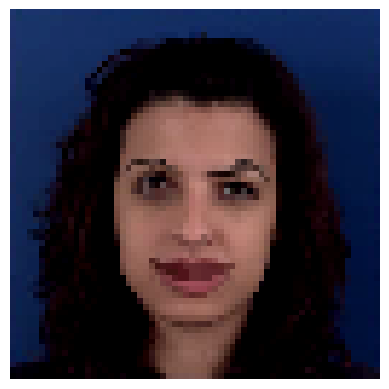

In [43]:
# Load the input image
image = normalized_sequence_to_images(current_video[0])
# conversion requested dtype string for Tensor with dtype uint8

landmarks1 = current_landmarks[0]
landmarks2 = current_landmarks[72]

# Define the triangles in the source and target images
triangles1 = landmarks1[DEFAULT_TRIANGULATION]
triangles2 = landmarks2[DEFAULT_TRIANGULATION]

# Warp the triangles in the image
warped_image = warp_all(image, triangles1, triangles2)

# Display the warped image
plt.imshow(warped_image)
plt.axis('off')
plt.show()
